In [ ]:
# ------ SETUP --------
from pathlib import Path
import time, heapq
from collections import deque
from math import radians, sin, cos, asin, sqrt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("all_datasets")
RESULTS = Path("results/lab01")
RESULTS.mkdir(parents=True, exist_ok=True)

In [ ]:
# ------ QUESTION 1 --------
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    a = sin((lat2 - lat1) / 2) ** 2 + cos(lat1) * cos(lat2) * sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371 * asin(sqrt(a))

In [9]:
airports = pd.read_csv(DATA / "lab01-03_airports.csv", header=None, na_values=["\\N"])
if not str(airports.iloc[0, 0]).strip().isdigit():     # first row is a header, so drop it
    airports = airports.iloc[1:]
airports = airports[[4, 6, 7]].copy()
airports.columns = ["iata", "latitude", "longitude"]
airports["latitude"] = pd.to_numeric(airports["latitude"], errors="coerce")
airports["longitude"] = pd.to_numeric(airports["longitude"], errors="coerce")
airport_rows = len(airports)

airports = airports.dropna(subset=["iata", "latitude", "longitude"])
airports = airports[airports["iata"].astype(str).str.fullmatch(r"[A-Z]{3}")]
airports = airports.drop_duplicates(subset="iata")
valid_airports = len(airports)
coords = airports.set_index("iata")[["latitude", "longitude"]].to_dict("index")

In [11]:
routes = pd.read_csv(DATA / "lab01-03_routes.csv", skipinitialspace=True)
routes = routes.rename(columns={"source airport": "source", "destination apirport": "destination"})
route_rows = len(routes)

routes = routes[routes["source"].isin(coords) & routes["destination"].isin(coords)]
routes = routes.drop_duplicates(subset=["source", "destination"])
unique_valid_routes = len(routes)

In [15]:
graph = {}
for r in routes.itertuples():
    a, b = coords[r.source], coords[r.destination]
    d = haversine_km(a["latitude"], a["longitude"], b["latitude"], b["longitude"])
    graph.setdefault(r.source, []).append((r.destination, d))

stats = {"airport_rows": airport_rows, "valid_airports": valid_airports,
         "route_rows": route_rows, "unique_valid_routes": unique_valid_routes,
         "removed_route_rows": route_rows - unique_valid_routes}
print(pd.Series(stats, name="count").to_frame())

queries = pd.DataFrame({"query_id": ["Q1", "Q2", "Q3"],
                        "start": ["KUL", "SIN", "NRT"],
                        "goal": ["KEF", "EZE", "CPT"]})
print(queries)

                     count
airport_rows         10668
valid_airports        6283
route_rows           67663
unique_valid_routes  37338
removed_route_rows   30325
  query_id start goal
0       Q1   KUL  KEF
1       Q2   SIN  EZE
2       Q3   NRT  CPT


In [ ]:
# ------ QUESTION 2 --------
sample = pd.DataFrame(graph["KUL"][:5], columns=["destination", "distance_km"])
print(sample.round(1))

direct_km = haversine_km(coords["KUL"]["latitude"], coords["KUL"]["longitude"],
                         coords["KEF"]["latitude"], coords["KEF"]["longitude"])
print(f"KUL has {len(graph['KUL'])} outgoing routes")
print(f"Great-circle distance KUL -> KEF: {direct_km:,.0f} km (no direct route exists)")

  destination  distance_km
0         SIN        297.5
1         DAC       2642.3
2         MNL       2489.9
3         RGN       1688.5
4         BLR       2883.6
KUL has 112 outgoing routes
Great-circle distance KUL -> KEF: 11,316 km (no direct route exists)


In [ ]:
# ------ QUESTION 3 --------
def make_result(graph, parent, goal, expanded, max_frontier, t0):
    if goal not in parent:                     # goal never reached
        return {"found": False, "hops": None, "path_cost_km": None, "expanded": expanded,
                "max_frontier": max_frontier, "runtime_ms": (time.time() - t0) * 1000, "path": []}
    path, node = [], goal
    while node is not None:                    # walk back from goal to start
        path.append(node)
        node = parent[node]
    path.reverse()
    edge_km = {}
    cost = sum(dict(graph[a])[b] for a, b in zip(path, path[1:]))
    return {"found": True, "hops": len(path) - 1, "path_cost_km": cost, "expanded": expanded,
            "max_frontier": max_frontier, "runtime_ms": (time.time() - t0) * 1000, "path": path}

In [19]:
def bfs(graph, start, goal):
    t0 = time.time()
    frontier = deque([start])
    parent = {start: None}
    expanded, max_f = 0, 1
    while frontier:
        node = frontier.popleft()              # oldest first
        expanded += 1
        if node == goal:
            break
        for nb, _ in graph.get(node, []):
            if nb not in parent:               # not discovered yet
                parent[nb] = node
                frontier.append(nb)
        max_f = max(max_f, len(frontier))
    return make_result(graph, parent, goal, expanded, max_f, t0)

In [20]:
def dfs(graph, start, goal):
    t0 = time.time()
    frontier = [(start, None)]
    parent, visited = {}, set()
    expanded, max_f = 0, 1
    while frontier:
        node, par = frontier.pop()             # newest first
        if node in visited:
            continue
        visited.add(node)
        parent[node] = par
        expanded += 1
        if node == goal:
            break
        for nb, _ in reversed(graph.get(node, [])):   # reversed so the FIRST neighbour is tried first
            if nb not in visited:
                frontier.append((nb, node))
        max_f = max(max_f, len(frontier))
    return make_result(graph, parent, goal, expanded, max_f, t0)

In [21]:
def ucs(graph, start, goal):
    t0 = time.time()
    frontier = [(0, start)]
    best = {start: 0}
    parent = {start: None}
    expanded, max_f = 0, 1
    while frontier:
        cost, node = heapq.heappop(frontier)   # cheapest first
        if cost > best[node]:                  # outdated, more expensive entry
            continue
        expanded += 1
        if node == goal:                       # test when popped, not when generated
            break
        for nb, d in graph.get(node, []):
            new_cost = cost + d
            if nb not in best or new_cost < best[nb]:
                best[nb] = new_cost
                parent[nb] = node
                heapq.heappush(frontier, (new_cost, nb))
        max_f = max(max_f, len(frontier))
    return make_result(graph, parent, goal, expanded, max_f, t0)

def route_is_valid(path, graph):
    return all(b in dict(graph.get(a, [])) for a, b in zip(path, path[1:]))

In [22]:
rows = []
for q in queries.itertuples():
    for name, algo in [("BFS", bfs), ("DFS", dfs), ("UCS", ucs)]:
        res = algo(graph, q.start, q.goal)
        res["path"] = " -> ".join(res["path"])
        rows.append({"query_id": q.query_id, "start": q.start, "goal": q.goal,
                     "algorithm": name, **res})
metrics = pd.DataFrame(rows).drop(columns="found")
metrics.to_csv(RESULTS / "metrics.csv", index=False)
print(metrics.drop(columns=["start", "goal", "path"]).round(2))

  query_id algorithm  hops  path_cost_km  expanded  max_frontier  runtime_ms
0       Q1       BFS     2      12683.04       428          1891        4.84
1       Q1       DFS   149     219532.81       160          7185        3.29
2       Q1       UCS     4      11461.33      1852           616        8.97
3       Q2       BFS     2      21825.10       557          1803        5.99
4       Q2       DFS   123     174214.54       138          5560        1.82
5       Q2       UCS     3      17817.33      3003           620        9.07
6       Q3       BFS     2      19272.42       992          1845        2.11
7       Q3       DFS   690     794891.31      1301         15645        5.35
8       Q3       UCS     3      14813.30      3043          1018        8.38


In [23]:
# ------ QUESTION 4 --------
edge_km = {a: dict(nbs) for a, nbs in graph.items()}
for row in metrics.itertuples():
    path = row.path.split(" -> ")
    assert route_is_valid(path, graph), f"{row.algorithm} {row.query_id}: a leg is not a real route"
    recomputed = sum(edge_km[a][b] for a, b in zip(path, path[1:]))
    assert np.isclose(recomputed, row.path_cost_km), f"{row.algorithm} {row.query_id}: cost mismatch"
print(f"Verified {len(metrics)} paths: every leg exists and every cost matches its edge sum")

Verified 9 paths: every leg exists and every cost matches its edge sum


In [27]:
# ------ QUESTION 5 --------
print(metrics.pivot(index="query_id", columns="algorithm",
                    values=["hops", "path_cost_km"]).round(0))

reversed_graph = {a: nbs[::-1] for a, nbs in graph.items()}
for q in queries.itertuples():
    original = dfs(graph, q.start, q.goal)["hops"]
    reordered = dfs(reversed_graph, q.start, q.goal)["hops"]
    print(f"{q.query_id} DFS: {original} hops with the original order, {reordered} with the reversed order")

          hops             path_cost_km                   
algorithm  BFS    DFS  UCS          BFS       DFS      UCS
query_id                                                  
Q1         2.0  149.0  4.0      12683.0  219533.0  11461.0
Q2         2.0  123.0  3.0      21825.0  174215.0  17817.0
Q3         2.0  690.0  3.0      19272.0  794891.0  14813.0
Q1 DFS: 149 hops with the original order, 25 with the reversed order
Q2 DFS: 123 hops with the original order, 451 with the reversed order
Q3 DFS: 690 hops with the original order, 626 with the reversed order


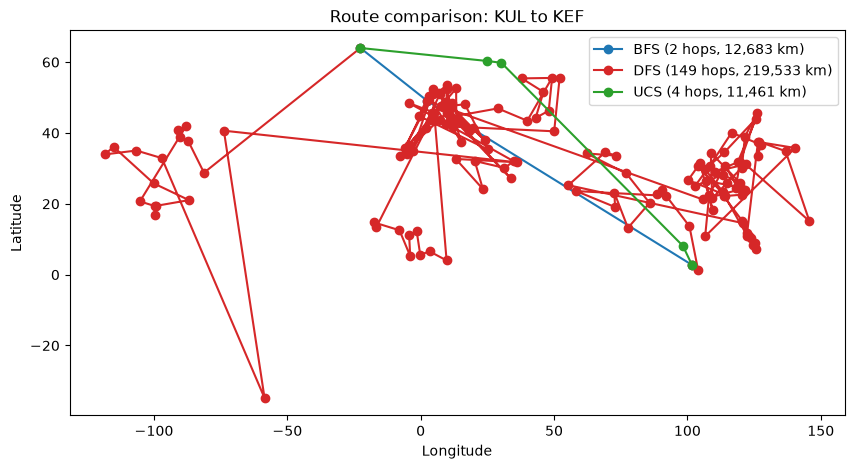

Saved: ['metrics.csv', 'route_comparison.png']


In [28]:
# ------ QUESTION 6 --------
q1 = metrics[metrics.query_id == "Q1"]
colors = {"BFS": "tab:blue", "DFS": "tab:red", "UCS": "tab:green"}

plt.figure(figsize=(10, 5))
for row in q1.itertuples():
    path = row.path.split(" -> ")
    lons = [coords[a]["longitude"] for a in path]
    lats = [coords[a]["latitude"] for a in path]
    plt.plot(lons, lats, marker="o", label=f"{row.algorithm} ({row.hops} hops, {row.path_cost_km:,.0f} km)",
             color=colors[row.algorithm])
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.title("Route comparison: KUL to KEF")
plt.legend()
plt.savefig(RESULTS / "route_comparison.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))